In [2]:
import os
import re
import pandas as pd
import numpy as np
import os
import glob
import re
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

from utils import ml_pipeline as ml
from utils import plotting

/Users/marialima/Desktop/Analysis/ml-analysis/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Sensitivity analysis on English-only and Spanish-only data from the pilot dataset (N=22)

In [5]:
df_liwc_train = pd.read_pickle('./liwc22-size100.pkl')
df_hri = pd.read_pickle("./df_liwc_all-size100.pkl")
df_hri_English = df_hri[df_hri['language'] == 'English']
df_hri_Spanish = df_hri[df_hri['language'] == 'Spanish']

In [4]:
len(df_hri_Spanish), len(df_hri_English)

(8, 14)

In [26]:
def perf_classif(df_train, df_test):
    # TRAIN
    X = df_train['data']
    y = df_train['label']
    X_train_2d = np.stack(X.values)
    # Normalization
    scaler = StandardScaler()
    X_scaled_train = scaler.fit_transform(X_train_2d)

    # TEST
    X_test = df_test['data']
    y_test = df_test['label']
    X_test_2d = np.stack(X_test.values)
    # Transform test set with scaler object already fit on training data
    X_scaled_test = scaler.transform(X_test_2d)
    best_hyperparams = ml.load_best_params_UPD(feature_set = 'w-liwc22')
    best_hyperparams = {'Random Forest': best_hyperparams['Random Forest']}
    print(best_hyperparams)

    evaluation_bootstrap, probs = ml.fit_and_evaluate_bootstrap_(best_hyperparams, X_scaled_train, y, X_scaled_test, y_test)
    evaluation_bootstrap_df = pd.DataFrame(evaluation_bootstrap)
    df = evaluation_bootstrap_df.round(3)
    df[df.columns[1:]] = df[df.columns[1:]] * 100
    results_dict = {}
    for model_name in df.Model:
        print(model_name)
        results = ml.extract_results_classif_test(df[df.Model == model_name])
        results_dict[model_name] = results
    return results_dict

All pilot dataset

In [27]:
results_dict = perf_classif(df_liwc_train, df_hri)
results_dict

./hyperparam-tuning-UPD/w-liwc22/10fcv_lr.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_svm.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_rf.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_nn.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_xgboost.pkl
{'Random Forest': RandomForestClassifier(max_depth=8, min_samples_split=5, n_estimators=350,
                       random_state=42)}
Random Forest


{'Random Forest': ('70.0 (60.7 - 79.3)',
  '50.0 (39.7 - 60.3)',
  '64.6 (59.6 - 69.7)',
  '62.7 (59.0 - 66.4)')}

English new predictions

In [28]:
results_dict = perf_classif(df_liwc_train, df_hri_English)
results_dict

./hyperparam-tuning-UPD/w-liwc22/10fcv_lr.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_svm.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_rf.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_nn.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_xgboost.pkl
{'Random Forest': RandomForestClassifier(max_depth=8, min_samples_split=5, n_estimators=350,
                       random_state=42)}
Random Forest


{'Random Forest': ('71.0 (61.8 - 80.2)',
  '60.0 (42.7 - 77.3)',
  '77.0 (70.8 - 83.2)',
  '67.9 (61.8 - 73.9)')}

Spanish new predictions

In [29]:
results_dict = perf_classif(df_liwc_train, df_hri_Spanish)
results_dict

./hyperparam-tuning-UPD/w-liwc22/10fcv_lr.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_svm.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_rf.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_nn.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_xgboost.pkl
{'Random Forest': RandomForestClassifier(max_depth=8, min_samples_split=5, n_estimators=350,
                       random_state=42)}
Random Forest


{'Random Forest': ('67.5 (52.8 - 82.2)',
  '40.0 (30.8 - 49.2)',
  '45.6 (36.7 - 54.6)',
  '53.8 (47.7 - 59.8)')}

Could this be due to different MMSE distributions in each language group?

In [3]:
print('Spanish')
print(df_hri_Spanish.mmse_split.value_counts())

print('English')
print(df_hri_English.mmse_split.value_counts())

Spanish
mmse_split
cn        4
ad-mil    4
Name: count, dtype: int64
English
mmse_split
ad-mil    8
cn        4
ad-mod    2
Name: count, dtype: int64


In [4]:
df_hri_Spanish.mmse.mean(), df_hri_English.mmse.mean()  

(26.125, 24.214285714285715)

In [5]:
df_hri_Spanish.mmse.std(), df_hri_English.mmse.std() 

(3.6030740843261686, 3.9453686856786994)

### WER per cognitive group

- further analysis on how ASR errors impact model performance would be beneficial.
- Is there a relationship between amount of ASR error and prediction of ADRD? 
- Exploring ASR robustness across different cognitive states could further strengthen the analysis

In [16]:
import os
import evaluate

def preprocess_text(text):
    """
    Preprocess text by stripping leading/trailing whitespace.
    Hugging Face WER handles punctuation and case normalization internally.
    """
    return text.strip()

def calc_wer(asr_folder, ref_folder):
    """
    Calculate average WER for files in ASR and reference folders using Hugging Face's evaluate.
    Assumes matching filenames in both folders.
    """
    wer_metric = evaluate.load("wer")

    asr_files = sorted(os.listdir(asr_folder))
    ref_files = sorted(os.listdir(ref_folder))
    asr_files = asr_files[1:]
    ref_files = ref_files[1:]   
    

    if len(asr_files) != len(ref_files):
        print("Mismatch in number of files between ASR and reference folders.")
        return

    predictions = []
    references = []
    wers = []  # individual WER scores

    for asr_file, ref_file in zip(asr_files, ref_files):
        asr_path = os.path.join(asr_folder, asr_file)
        ref_path = os.path.join(ref_folder, ref_file)

        with open(asr_path, 'r', encoding='ISO-8859-1') as f_asr, open(ref_path, 'r', encoding='ISO-8859-1') as f_ref:
            asr_text = preprocess_text(f_asr.read())
            ref_text = preprocess_text(f_ref.read())
            print(asr_text, ref_text)
            predictions.append(asr_text)
            references.append(ref_text)

            # Calculate individual WER
            file_wer = wer_metric.compute(predictions=[asr_text], references=[ref_text])
            wers.append(file_wer)

    avg_wer = wer_metric.compute(predictions=predictions, references=references)

    # Compute standard deviation
    std_wer = np.std(wers, ddof=1)

    print(f"\nAverage WER: {avg_wer:.2%}")
    print(f"Standard Deviation of WER: {std_wer:.2%}")

In [17]:
# Update these paths to your folders
asr_folder_path = "./asr"
ref_folder_path = "./manual"
asr_files = sorted(os.listdir(asr_folder_path))
ref_files = sorted(os.listdir(ref_folder_path))
asr_files = asr_files[1:]
ref_files = ref_files[1:]

excluded_pids = {"adrso277", "adrso043"}  # use a set for efficiency

asr_files = [f for f in asr_files if not any(pid in f for pid in excluded_pids)]
ref_files = [f for f in ref_files if not any(pid in f for pid in excluded_pids)]
print(len(asr_files), len(ref_files))
print(asr_files[:5])

# Set remove_punctuation=True to remove punctuation
calc_wer(asr_folder_path, ref_folder_path)

145 145
['stt_adrso002.txt', 'stt_adrso003.txt', 'stt_adrso005.txt', 'stt_adrso007.txt', 'stt_adrso008.txt']
Okay, I see a mom doing the dishes and the water's overflowing from the sink and she seems to be completely oblivious of it. The children in the picture, who I presume are hers, are climbing, one of the boys climbing on a, or standing on a stool that's about to fall over, putting his hand in the cookie jar on the top shelf and his sister or cousin or whoever the girl is, is reaching up for a cookie. The window is open, there's a pathway with garden on either side, it looks like. There's something else on the sink, I mean on the countertop, dishes. And that's, the mother has an apron on, she is dressed in the Mrs. Beaver style with a very, with an apron and a nice dress and shoes and so forth, and I don't understand why she's not turning the water off, but that's part of the deal. And there's curtains on the window and there's panes in the window, small panes. Okay, I see a mom d

In [3]:
# Update these paths to your folders
asr_folder_path = "./asr"
ref_folder_path = "./manual"
asr_files = sorted(os.listdir(asr_folder_path))
ref_files = sorted(os.listdir(ref_folder_path))
asr_files = asr_files[1:]
ref_files = ref_files[1:]

excluded_pids = {"adrso277", "adrso043"}  # use a set for efficiency

asr_files = [f for f in asr_files if not any(pid in f for pid in excluded_pids)]
ref_files = [f for f in ref_files if not any(pid in f for pid in excluded_pids)]
print(len(asr_files), len(ref_files))

# Set remove_punctuation=True to remove punctuation
calc_wer(asr_folder_path, ref_folder_path)

145 145

Average WER: 15.70%


In [18]:
asr_files = [re.search(r'_(.*?)\.', file).group(1) for file in asr_files]

# Read the CSV file
df = pd.read_csv('./dx-mmse.csv')

# Select only the specified columns
selected_columns = ['age', 'gender', 'mmse', 'dx', 'adressfname', 'test']
df = df[selected_columns]

df.loc[df['mmse'] < 10, 'mmse_split'] = 'ad-sev'
df.loc[(df['mmse'] >= 10) & (df['mmse'] <= 20), 'mmse_split'] = 'ad-mod'
df.loc[(df['mmse'] >= 21) & (df['mmse'] <= 26), 'mmse_split'] = 'ad-mil'
df.loc[df['mmse'] > 26, 'mmse_split'] = 'cn'

# Filter the groups DataFrame based on the extracted file IDs
manual_check = df[df['adressfname'].isin(asr_files)]
manual_check

,age,gender,mmse,dx,adressfname,test,mmse_split
0,70,female,26.0,Control,adrso002,False,ad-mil
1,72,female,30.0,Control,adrso003,False,cn
3,67,female,27.0,Control,adrso005,False,cn
5,62,female,30.0,Control,adrso007,False,cn
6,67,female,29.0,Control,adrso008,False,cn
...,...,...,...,...,...,...,...
196,67,female,30.0,Control,adrso273,False,cn
197,70,female,30.0,Control,adrso274,False,cn
199,73,female,29.0,Control,adrso276,False,cn
201,64,male,28.0,Control,adrso278,False,cn


In [19]:
manual_check.mmse_split.value_counts()

mmse_split
ad-mod    62
cn        59
ad-mil    20
ad-sev     4
Name: count, dtype: int64

### WER per Cog group 

In [46]:
manual_check.mmse_split.value_counts()

mmse_split
ad-mod    62
cn        59
ad-mil    20
ad-sev     4
Name: count, dtype: int64

In [79]:
print(f'CN {59/114}')
print(f'AD-mild {20/33}')
print(f'AD-mod {62/83}')
print(f'AD-sev {4/6}')

CN 0.5175438596491229
AD-mild 0.6060606060606061
AD-mod 0.7469879518072289
AD-sev 0.6666666666666666


Filter by group

In [12]:
# Filter manual_check for rows where mmse_split is 'cn'
cn_pid = manual_check[manual_check['mmse_split'] == 'cn']['adressfname'].tolist()
ad_mild_pid = manual_check[manual_check['mmse_split'] == 'ad-mil']['adressfname'].tolist()
ad_mod_pid = manual_check[manual_check['mmse_split'] == 'ad-mod']['adressfname'].tolist()
ad_sev_pid = manual_check[manual_check['mmse_split'] == 'ad-sev']['adressfname'].tolist()
# Display the list
len(cn_pid), len(ad_mild_pid), len(ad_mod_pid), len(ad_sev_pid)


(59, 20, 62, 4)

In [13]:
# Filter asr_files for entries that match any of the strings in cn_pid
cn_asr = [file for file in asr_files if any(cn_id in file for cn_id in cn_pid)]
ad_mild_asr = [file for file in asr_files if any(ad_mild_id in file for ad_mild_id in ad_mild_pid)]
ad_mod_asr = [file for file in asr_files if any(ad_mod_id in file for ad_mod_id in ad_mod_pid)]
ad_sev_asr = [file for file in asr_files if any(ad_sev_id in file for ad_sev_id in ad_sev_pid)]

cn_manual = [file for file in ref_files if any(cn_id in file for cn_id in cn_pid)]
ad_mild_manual = [file for file in ref_files if any(ad_mild_id in file for ad_mild_id in ad_mild_pid)]
ad_mod_manual = [file for file in ref_files if any(ad_mod_id in file for ad_mod_id in ad_mod_pid)]
ad_sev_manual = [file for file in ref_files if any(ad_sev_id in file for ad_sev_id in ad_sev_pid)]

len(cn_asr), len(ad_mild_asr), len(ad_mod_asr), len(ad_sev_asr)

(59, 20, 62, 4)

In [14]:
import os
import evaluate

def preprocess_text(text):
    return text.strip()

def calc_wer_filtered(asr_folder, ref_folder, pid_list):
    """
    Calculate WER only for files whose filenames match PIDs in the provided list.
    """
    wer_metric = evaluate.load("wer")
    
    asr_files = sorted(os.listdir(asr_folder))
    ref_files = sorted(os.listdir(ref_folder))

    # Filter files that match any PID in the list
    selected_asr = [f for f in asr_files if any(pid in f for pid in pid_list)]
    selected_ref = [f for f in ref_files if any(pid in f for pid in pid_list)]

    # Sort to maintain alignment
    selected_asr.sort()
    selected_ref.sort()

    print('First', selected_asr[0])

    if len(selected_asr) != len(selected_ref):
        print("Warning: ASR and REF file counts do not match after filtering.")
    
    predictions = []
    references = []

    for asr_file, ref_file in zip(selected_asr, selected_ref):
        with open(os.path.join(asr_folder, asr_file), 'r', encoding='utf-8') as f_asr, \
             open(os.path.join(ref_folder, ref_file), 'r', encoding='utf-8') as f_ref:

            asr_text = preprocess_text(f_asr.read())
            ref_text = preprocess_text(f_ref.read())
            # print(f"Processing: {asr_file}")
            predictions.append(asr_text)
            references.append(ref_text)

    print(f"\nTotal files processed: {len(predictions)}")
    avg_wer = wer_metric.compute(predictions=predictions, references=references)
    print(f"Average WER: {avg_wer:.2%}")


In [50]:
asr_path = './asr'
ref_path = './manual'

calc_wer_filtered(asr_path, ref_path, cn_pid)

First stt_adrso003.txt

Total files processed: 59
Average WER: 9.22%


In [51]:
asr_path = './asr'
ref_path = './manual'

calc_wer_filtered(asr_path, ref_path, ad_mild_pid)

First stt_adrso002.txt

Total files processed: 20
Average WER: 14.93%


In [52]:
asr_path = './asr'
ref_path = './manual'

calc_wer_filtered(asr_path, ref_path, ad_mod_pid)

First stt_adrso024.txt

Total files processed: 62
Average WER: 20.52%


In [53]:
asr_path = './asr'
ref_path = './manual'

calc_wer_filtered(asr_path, ref_path, ad_sev_pid)

First stt_adrso033.txt

Total files processed: 4
Average WER: 31.89%


### WER per PID

In [32]:
import os
import evaluate
import pandas as pd
import matplotlib.pyplot as plt

def preprocess_text(text):
    return text.strip()

def compute_wer_per_pid(asr_folder, ref_folder, pid_list):
    """
    Compute WER for each participant (pid).
    Assumes one file per pid in each folder.
    Returns: dict {pid: WER}
    """
    wer_metric = evaluate.load("wer")
    pid_to_wer = {}

    for pid in pid_list:
        # Find corresponding file
        asr_file = next((f for f in os.listdir(asr_folder) if pid in f), None)
        ref_file = next((f for f in os.listdir(ref_folder) if pid in f), None)

        if not asr_file or not ref_file:
            print(f"Missing files for {pid}")
            continue

        with open(os.path.join(asr_folder, asr_file), 'r', encoding='utf-8') as f_asr, \
             open(os.path.join(ref_folder, ref_file), 'r', encoding='utf-8') as f_ref:
            asr_text = preprocess_text(f_asr.read())
            ref_text = preprocess_text(f_ref.read())

        wer = wer_metric.compute(predictions=[asr_text], references=[ref_text])
        pid_to_wer[pid] = wer

    return pid_to_wer

In [33]:
asr_path = './asr'
ref_path = './manual'

In [34]:
pid_list = manual_check['adressfname'].tolist()

# Get WER per pid
pid_wer_dict = compute_wer_per_pid(asr_path, ref_path, pid_list)

In [35]:
pid_wer_dict

{'adrso002': 0.05172413793103448,
 'adrso003': 0.058823529411764705,
 'adrso005': 0.04861111111111111,
 'adrso007': 0.06153846153846154,
 'adrso008': 0.02142857142857143,
 'adrso010': 0.06976744186046512,
 'adrso012': 0.09154929577464789,
 'adrso014': 0.06944444444444445,
 'adrso015': 0.16161616161616163,
 'adrso016': 0.1,
 'adrso017': 0.04950495049504951,
 'adrso018': 0.08088235294117647,
 'adrso019': 0.05714285714285714,
 'adrso021': 0.049079754601226995,
 'adrso022': 0.0,
 'adrso023': 0.08333333333333333,
 'adrso024': 0.10891089108910891,
 'adrso025': 0.21243523316062177,
 'adrso027': 0.18181818181818182,
 'adrso028': 0.3220338983050847,
 'adrso031': 0.04672897196261682,
 'adrso032': 0.3202247191011236,
 'adrso033': 0.15714285714285714,
 'adrso035': 0.20987654320987653,
 'adrso036': 0.2962962962962963,
 'adrso039': 0.25,
 'adrso045': 0.28214285714285714,
 'adrso046': 0.13636363636363635,
 'adrso047': 0.19444444444444445,
 'adrso049': 0.36809815950920244,
 'adrso053': 0.2217194570135

In [36]:
len(pid_wer_dict)

145

In [37]:
manual_check['wer'] = manual_check['adressfname'].map(
    lambda pid: round(pid_wer_dict[pid]*100, 2) if pid in pid_wer_dict else None
)

/var/folders/lm/sz7z6d6x725_9nyqv0hzt1jm0000gn/T/ipykernel_80014/615001028.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  manual_check['wer'] = manual_check['adressfname'].map(


In [38]:
manual_check.head()

,age,gender,mmse,dx,adressfname,test,mmse_split,wer
0,70,female,26.0,Control,adrso002,False,ad-mil,5.17
1,72,female,30.0,Control,adrso003,False,cn,5.88
3,67,female,27.0,Control,adrso005,False,cn,4.86
5,62,female,30.0,Control,adrso007,False,cn,6.15
6,67,female,29.0,Control,adrso008,False,cn,2.14


In [39]:
# Order manual_check by 'wer' in ascending order
manual_check_sorted = manual_check.sort_values(by='wer', ascending=False)

# Display the sorted DataFrame
manual_check_sorted.head(10)

,age,gender,mmse,dx,adressfname,test,mmse_split,wer
87,74,male,17.0,ProbableAD,adrso130,False,ad-mod,75.00
81,77,male,14.0,ProbableAD,adrso122,False,ad-mod,66.67
85,78,female,18.0,ProbableAD,adrso126,False,ad-mod,58.06
86,55,female,20.0,ProbableAD,adrso128,False,ad-mod,56.67
47,65,male,28.0,ProbableAD,adrso056,False,cn,55.83
49,75,female,15.0,ProbableAD,adrso060,False,ad-mod,53.33
77,70,female,12.0,ProbableAD,adrso116,False,ad-mod,51.56
45,60,female,12.0,ProbableAD,adrso054,False,ad-mod,47.83
56,66,female,19.0,ProbableAD,adrso070,False,ad-mod,44.23
150,56,female,24.0,ProbableAD,adrso216,False,ad-mil,44.00


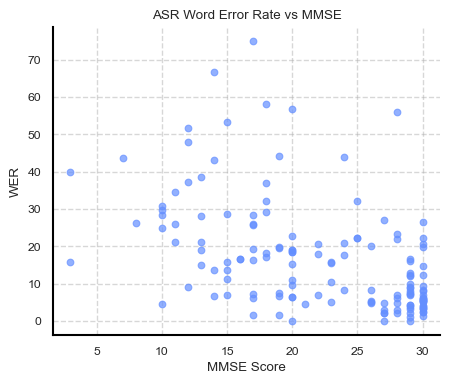

In [45]:
# Plot MMSE vs WER
plot_df = manual_check.dropna(subset=['wer', 'mmse'])

with plotting.paper_theme():
    plt.figure(figsize=(5, 4))
    plt.scatter(plot_df['mmse'], plot_df['wer'], alpha=0.7)
    plt.xlabel('MMSE Score')
    plt.ylabel('WER')
    plt.title('ASR Word Error Rate vs MMSE')
    plt.grid(True)
    plt.show()

<Figure size 500x400 with 0 Axes>

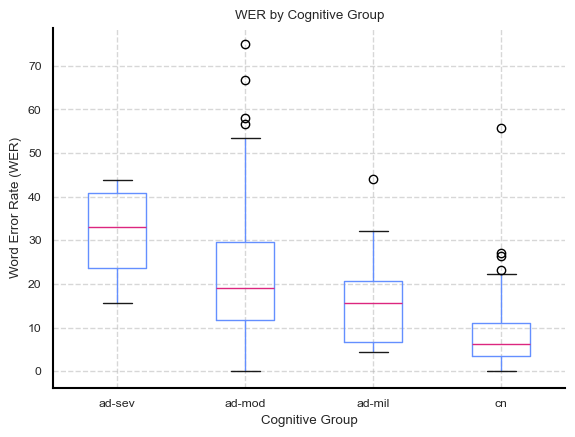

In [47]:
import matplotlib.pyplot as plt

# Drop missing WER values
plot_df = manual_check.dropna(subset=['wer', 'mmse_split'])

# Optional: enforce group order
group_order = ['ad-sev', 'ad-mod', 'ad-mil', 'cn']  # if this order matters
plot_df['mmse_split'] = pd.Categorical(plot_df['mmse_split'], categories=group_order, ordered=True)

with plotting.paper_theme():
    plt.close()
    # Create the boxplot
    plt.figure(figsize=(5,4))
    plot_df.boxplot(column='wer', by='mmse_split')
    plt.title("WER by Cognitive Group")
    plt.suptitle("")  # remove the automatic title from pandas
    plt.xlabel("Cognitive Group")
    plt.ylabel("Word Error Rate (WER)")
    plt.grid(True)
    plt.show()


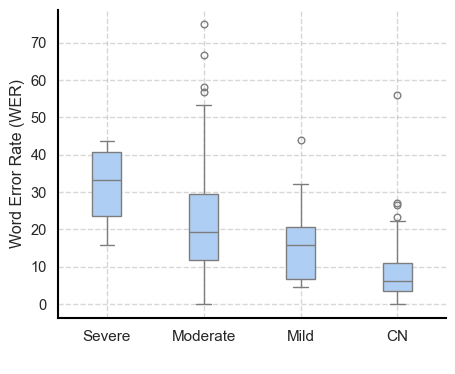

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator  # optional, only if you want significance annotations
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors

# Drop missing WER values
plot_df = manual_check.dropna(subset=['wer', 'mmse_split'])

# Enforce group order
group_order = ['ad-sev', 'ad-mod', 'ad-mil', 'cn']
plot_df['mmse_split'] = pd.Categorical(plot_df['mmse_split'], categories=group_order, ordered=True)

colors = [
    'xkcd:marine blue',# "#104E8B",  # dark blue
    'xkcd:cerulean',# 'xkcd:bright blue'
    'xkcd:baby blue',
]  
colors = [mcolors.to_rgba(c, alpha=0.90) for c in colors]

with plotting.paper_theme():
    plt.close()
    plt.figure(figsize=(5,4))

    # Create Seaborn boxplot with a specific colour and transparency
    boxplot = sns.boxplot(x='mmse_split', y='wer', data=plot_df,
                          order=group_order, color=colors[2], width=0.3)

    for patch in boxplot.artists:
        patch.set_alpha(0.8)

    plt.xlabel(' ', fontsize=11.5)
    plt.xticks(ticks=np.arange(len(group_order)), labels=['Severe', 'Moderate', 'Mild', 'CN'], fontsize=11)
    plt.ylabel('Word Error Rate (WER)', fontsize=11.5)
    plt.yticks(fontsize=10.5)

    # Save if needed
    plt.savefig('./wer_by_group.pdf', dpi=600, bbox_inches='tight')
    plt.savefig('./wer_by_group.png', dpi=600, bbox_inches='tight')

    plt.title('', fontsize=13, pad=15)
    plt.grid(True)
    plt.show()


In [47]:
plot_df

,age,gender,mmse,dx,adressfname,test,mmse_split,wer
0,70,female,26.0,Control,adrso002,False,ad-mil,5.17
1,72,female,30.0,Control,adrso003,False,cn,5.88
3,67,female,27.0,Control,adrso005,False,cn,4.86
5,62,female,30.0,Control,adrso007,False,cn,6.15
6,67,female,29.0,Control,adrso008,False,cn,2.14
...,...,...,...,...,...,...,...,...
196,67,female,30.0,Control,adrso273,False,cn,3.57
197,70,female,30.0,Control,adrso274,False,cn,4.12
199,73,female,29.0,Control,adrso276,False,cn,1.18
201,64,male,28.0,Control,adrso278,False,cn,21.82


In [48]:
# Group by 'mmse_split' and calculate mean and std of 'wer'
group_stats_wer = plot_df.groupby('mmse_split')['wer'].agg(['mean', 'std']).reset_index()
group_stats_wer

/var/folders/lm/sz7z6d6x725_9nyqv0hzt1jm0000gn/T/ipykernel_2131/123063225.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats_wer = plot_df.groupby('mmse_split')['wer'].agg(['mean', 'std']).reset_index()


,mmse_split,mean,std
0,ad-sev,31.395000,12.846075
1,ad-mod,23.525323,16.464070
2,ad-mil,15.379000,10.311134
3,cn,8.939153,9.135146


### WER per pid with 10 predictions (one per fold) 

In [20]:
df_probs = pd.read_pickle('./df_probs_2.pkl')
df_probs.head()

,Predicted_Prob,True_Label
0,0.414190,0
1,0.268214,0
2,0.519063,0
3,0.528136,0
4,0.302866,0


In [21]:
df_probs['pid'] = df_liwc_train['pid'].astype(str)
df_probs.head()

,Predicted_Prob,True_Label,pid
0,0.414190,0,267
1,0.268214,0,273
2,0.519063,0,298
3,0.528136,0,307
4,0.302866,0,312


In [40]:
df_merge = manual_check.copy()

In [41]:
# Extract numeric pid from adressfname in df_merge
df_merge['pid'] = df_merge['adressfname'].str.extract(r'adrso(\d+)')

df_merge['pid'] = df_merge['pid'].astype(str)

df_probs['pid'] = df_probs['pid'].astype(str)
df_probs.head()

,Predicted_Prob,True_Label,pid
0,0.414190,0,267
1,0.268214,0,273
2,0.519063,0,298
3,0.528136,0,307
4,0.302866,0,312


In [25]:
df_merge

,age,gender,mmse,dx,adressfname,test,mmse_split,pid
0,70,female,26.0,Control,adrso002,False,ad-mil,002
1,72,female,30.0,Control,adrso003,False,cn,003
3,67,female,27.0,Control,adrso005,False,cn,005
5,62,female,30.0,Control,adrso007,False,cn,007
6,67,female,29.0,Control,adrso008,False,cn,008
...,...,...,...,...,...,...,...,...
196,67,female,30.0,Control,adrso273,False,cn,273
197,70,female,30.0,Control,adrso274,False,cn,274
199,73,female,29.0,Control,adrso276,False,cn,276
201,64,male,28.0,Control,adrso278,False,cn,278


In [43]:
# Step 2: Merge df_probs with selected columns from df_merge
columns_to_add = ['age', 'gender', 'mmse', 'dx', 'wer', 'mmse_split', 'pid']
df_final = df_probs.merge(df_merge[columns_to_add], left_on='pid', right_on='pid', how='left')

# Step 3: Drop redundant merge key if needed
df_final = df_final.dropna()
df_final

,Predicted_Prob,True_Label,pid,age,gender,mmse,dx,wer,mmse_split
0,0.414190,0,267,64.0,female,30.0,Control,2.41,cn
1,0.268214,0,273,67.0,female,30.0,Control,3.57,cn
6,0.480881,0,266,63.0,female,30.0,Control,5.49,cn
7,0.304040,0,270,61.0,female,30.0,Control,12.17,cn
8,0.447349,0,264,73.0,male,29.0,Control,12.37,cn
...,...,...,...,...,...,...,...,...,...
161,0.596000,1,055,65.0,female,17.0,ProbableAD,16.22,ad-mod
162,0.554976,1,109,70.0,female,20.0,ProbableAD,19.09,ad-mod
163,0.544595,1,134,79.0,female,8.0,ProbableAD,26.32,ad-sev
164,0.883762,1,054,60.0,female,12.0,ProbableAD,47.83,ad-mod


In [44]:
df_final.mmse_split.value_counts()

mmse_split
ad-mod    62
cn        59
ad-mil    20
ad-sev     4
Name: count, dtype: int64

Wihout considering each fold as a different data sample

In [30]:
# Step 1: Compute mean predicted probability across folds
fold_cols = [f'Fold_{i+1}' for i in range(10)]
df_final['mean_pred'] = df_final[fold_cols].mean(axis=1)
df_final

,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Fold_6,Fold_7,Fold_8,Fold_9,Fold_10,True_Label,pid,age,gender,mmse,dx,mmse_split,wer,mean_pred
0,0.273714,0.196333,0.215857,0.414190,0.343865,0.180254,0.232753,0.216000,0.248437,0.208881,0,267,64.0,female,30.0,Control,cn,2.41,0.253028
1,0.268214,0.053000,0.101310,0.087381,0.151778,0.131476,0.133667,0.081238,0.103333,0.156833,0,273,67.0,female,30.0,Control,cn,3.57,0.126823
6,0.255286,0.480881,0.379190,0.252159,0.202667,0.256206,0.247111,0.206333,0.255789,0.206429,0,266,63.0,female,30.0,Control,cn,5.49,0.274205
7,0.196905,0.170333,0.184167,0.179667,0.069000,0.106683,0.078333,0.162111,0.304040,0.162333,0,270,61.0,female,30.0,Control,cn,12.17,0.161357
8,0.447349,0.262333,0.218238,0.226111,0.247873,0.277071,0.169921,0.146635,0.207833,0.223008,0,264,73.0,male,29.0,Control,cn,12.37,0.242637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,0.739262,0.718722,0.745580,0.846333,0.596000,0.718635,0.691381,0.735659,0.766249,0.734444,1,055,65.0,female,17.0,ProbableAD,ad-mod,16.22,0.729227
162,0.765944,0.554976,0.843286,0.716167,0.775810,0.746262,0.772143,0.758175,0.671611,0.690392,1,109,70.0,female,20.0,ProbableAD,ad-mod,19.09,0.729477
163,0.648690,0.785778,0.781722,0.544595,0.780619,0.824389,0.718532,0.733849,0.714405,0.717286,1,134,79.0,female,8.0,ProbableAD,ad-sev,26.32,0.724987
164,0.894111,0.903667,0.892667,0.911333,0.883762,0.951587,0.893452,0.939778,0.946667,0.959143,1,054,60.0,female,12.0,ProbableAD,ad-mod,47.83,0.917617


In [35]:
df_final.mean_pred

0      0.253028
1      0.126823
6      0.274205
7      0.161357
8      0.242637
         ...   
161    0.729227
162    0.729477
163    0.724987
164    0.917617
165    0.700233
Name: mean_pred, Length: 145, dtype: float64

In [29]:
# Step 2: Convert mean prediction to binary label
df_final['mean_pred_label'] = (df_final['Predicted_Prob'] >= 0.5).astype(int)
df_final


,Predicted_Prob,True_Label,pid,age,gender,mmse,dx,mmse_split,mean_pred_label
0,0.414190,0,267,64.0,female,30.0,Control,cn,0
1,0.268214,0,273,67.0,female,30.0,Control,cn,0
6,0.480881,0,266,63.0,female,30.0,Control,cn,0
7,0.304040,0,270,61.0,female,30.0,Control,cn,0
8,0.447349,0,264,73.0,male,29.0,Control,cn,0
...,...,...,...,...,...,...,...,...,...
161,0.596000,1,055,65.0,female,17.0,ProbableAD,ad-mod,1
162,0.554976,1,109,70.0,female,20.0,ProbableAD,ad-mod,1
163,0.544595,1,134,79.0,female,8.0,ProbableAD,ad-sev,1
164,0.883762,1,054,60.0,female,12.0,ProbableAD,ad-mod,1


In [45]:
# Step 1: Compute mean predicted probability across folds
# fold_cols = [f'Fold_{i+1}' for i in range(10)]
# df_final['mean_pred'] = df_final[fold_cols].mean(axis=1)

# Step 2: Convert mean prediction to binary label
df_final['mean_pred_label'] = (df_final['Predicted_Prob'] >= 0.5).astype(int)

# Step 3: Compare to true label
df_final['correct'] = (df_final['mean_pred_label'] == df_final['True_Label']).astype(int)

# Step 4: Bin by WER
bins = [0, 10, 20, 30, 40, 100]
labels = ['[0-10]', '[10-20]', '[20-30]', '[30-40]', '[40-100]']
df_final['wer_bin'] = pd.cut(df_final['wer'], bins=bins, labels=labels, right=False)

# Step 5: Compute accuracy per bin
accuracy_by_bin = df_final.groupby('wer_bin')['correct'].mean().reset_index()
accuracy_by_bin.rename(columns={'correct': 'Accuracy'}, inplace=True)
accuracy_by_bin

/var/folders/lm/sz7z6d6x725_9nyqv0hzt1jm0000gn/T/ipykernel_80014/1997612191.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_by_bin = df_final.groupby('wer_bin')['correct'].mean().reset_index()


,wer_bin,Accuracy
0,[0-10],0.707692
1,[10-20],0.685714
2,[20-30],0.680000
3,[30-40],0.875000
4,[40-100],0.833333


@Alex: All 1.0?!? Odd...

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define WER bins
bins = [0, 10, 20, 30, 100]
labels = ['[0-10]', '[10-20]', '[20-30]', '[30-100]']
df_final['wer_bin'] = pd.cut(df_final['wer'], bins=bins, labels=labels, right=False)

# Step 2: Collect accuracy per fold per bin
records = []

for fold in range(10):
    fold_col = f'Fold_{fold + 1}'
    preds = (df_final[fold_col] >= 0.5).astype(int)  # binary predictions
    true = df_final['True_Label']

    for bin_label in labels:
        bin_mask = df_final['wer_bin'] == bin_label
        if bin_mask.sum() > 0:
            acc = (preds[bin_mask].values == true[bin_mask].values).mean()
            records.append({
                'Fold': fold + 1,
                'WER Bin': bin_label,
                'Accuracy': acc
            })

df_acc_by_bin = pd.DataFrame(records)
df_acc_by_bin

,Fold,WER Bin,Accuracy
0,1,[0-10],0.984615
1,1,[10-20],1.000000
2,1,[20-30],0.960000
3,1,[30-100],0.950000
4,2,[0-10],0.984615
5,2,[10-20],0.971429
6,2,[20-30],1.000000
7,2,[30-100],0.950000
8,3,[0-10],1.000000
9,3,[10-20],1.000000


In [71]:
# Get only the 10 fold prediction columns
fold_cols = [f'Fold_{i+1}' for i in range(10)]
pred_matrix = df_final[fold_cols].values >= 0.5  # shape: (n_samples, 10)
true_labels = df_final['True_Label'].values.reshape(-1, 1)  # shape: (n_samples, 1)

# Compare each fold's prediction with true label: gives a (n_samples, 10) boolean matrix
correct_matrix = (pred_matrix == true_labels).astype(int)

# Compute per-sample accuracy across folds
df_final['sample_accuracy'] = correct_matrix.mean(axis=1)

bins = [0, 10, 20, 30, 100]
labels = ['[0-10]', '[10-20]', '[20-30]', '[30-100]']
df_final['wer_bin'] = pd.cut(df_final['wer'], bins=bins, labels=labels, right=False)

df_final

,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Fold_6,Fold_7,Fold_8,Fold_9,Fold_10,...,gender,mmse,dx,mmse_split,wer,mean_pred,mean_pred_label,correct,wer_bin,sample_accuracy
0,0.273714,0.196333,0.215857,0.414190,0.343865,0.180254,0.232753,0.216000,0.248437,0.208881,...,female,30.0,Control,cn,2.41,0.253028,0,1,[0-10],1.0
1,0.268214,0.053000,0.101310,0.087381,0.151778,0.131476,0.133667,0.081238,0.103333,0.156833,...,female,30.0,Control,cn,3.57,0.126823,0,1,[0-10],1.0
6,0.255286,0.480881,0.379190,0.252159,0.202667,0.256206,0.247111,0.206333,0.255789,0.206429,...,female,30.0,Control,cn,5.49,0.274205,0,1,[0-10],1.0
7,0.196905,0.170333,0.184167,0.179667,0.069000,0.106683,0.078333,0.162111,0.304040,0.162333,...,female,30.0,Control,cn,12.17,0.161357,0,1,[10-20],1.0
8,0.447349,0.262333,0.218238,0.226111,0.247873,0.277071,0.169921,0.146635,0.207833,0.223008,...,male,29.0,Control,cn,12.37,0.242637,0,1,[10-20],1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,0.739262,0.718722,0.745580,0.846333,0.596000,0.718635,0.691381,0.735659,0.766249,0.734444,...,female,17.0,ProbableAD,ad-mod,16.22,0.729227,1,1,[10-20],1.0
162,0.765944,0.554976,0.843286,0.716167,0.775810,0.746262,0.772143,0.758175,0.671611,0.690392,...,female,20.0,ProbableAD,ad-mod,19.09,0.729477,1,1,[10-20],1.0
163,0.648690,0.785778,0.781722,0.544595,0.780619,0.824389,0.718532,0.733849,0.714405,0.717286,...,female,8.0,ProbableAD,ad-sev,26.32,0.724987,1,1,[20-30],1.0
164,0.894111,0.903667,0.892667,0.911333,0.883762,0.951587,0.893452,0.939778,0.946667,0.959143,...,female,12.0,ProbableAD,ad-mod,47.83,0.917617,1,1,[30-100],1.0


In [72]:
# Step 1: Select fold columns
fold_cols = [f'Fold_{i+1}' for i in range(10)]

# Step 2: Calculate mean and standard deviation across folds
df_final['mean_pred'] = df_final[fold_cols].mean(axis=1)
df_final['std_pred'] = df_final[fold_cols].std(axis=1)

# Step 3: Group by cognitive group (mmse_split) and calculate mean and std
group_stats = df_final.groupby('mmse_split').agg(
    mean_predicted_probability=('mean_pred', 'mean'),
    std_predicted_probability=('mean_pred', 'std')
).reset_index()

# Display the results
group_stats

,mmse_split,mean_predicted_probability,std_predicted_probability
0,ad-mil,0.648795,0.185470
1,ad-mod,0.781114,0.108223
2,ad-sev,0.843497,0.098738
3,cn,0.265436,0.125886


### Plot with 2 data types: WER, performance on the validation set 

In [73]:
df_plot = df_final.copy()

In [75]:
import matplotlib.pyplot as plt

# Step 1: Compute required group stats
group_stats = df_plot.groupby('mmse_split').agg(
    mean_pred=('mean_pred', 'mean'),
    std_pred=('mean_pred', 'std'),
    mean_wer=('wer', 'mean'),
    count=('pid', 'count')  # Optional, if needed
).reindex(['ad-sev', 'ad-mod', 'ad-mil', 'cn'])  # ensure group order
group_stats


,mean_pred,std_pred,mean_wer,count
mmse_split,,,,
ad-sev,0.843497,0.098738,31.395000,4
ad-mod,0.781114,0.108223,23.525323,62
ad-mil,0.648795,0.185470,15.379000,20
cn,0.265436,0.125886,8.939153,59


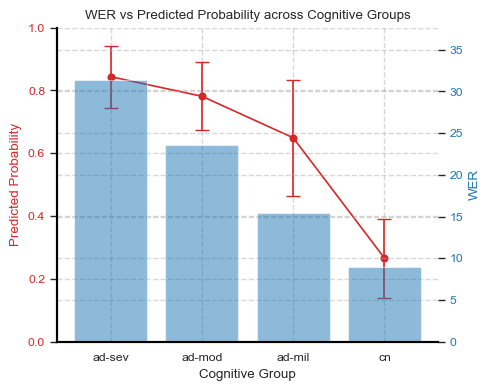

In [76]:
# Step 2: Prepare values
groups = group_stats.index.tolist()
mean_pred = group_stats['mean_pred'].values
std_pred = group_stats['std_pred'].values
mean_wer = group_stats['mean_wer'].values

with plotting.paper_theme():
    plt.close()
    # Step 3: Plot
    fig, ax1 = plt.subplots(figsize=(5,4))

    # Right axis: WER bar plot
    ax2 = ax1.twinx()
    ax2.bar(groups, mean_wer, alpha=0.5, color='tab:blue', label='Mean WER')
    ax2.set_ylabel('WER', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim(0, max(mean_wer)*1.2)

    # Left axis: Model performance (predicted probability)
    ax1.errorbar(groups, mean_pred, yerr=std_pred, fmt='o-', color='tab:red',
                ecolor='tab:red', capsize=5, label='Predicted Probability')
    ax1.set_ylabel('Predicted Probability', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_ylim(0, 1)

    # Styling
    ax1.set_title('WER vs Predicted Probability across Cognitive Groups')
    ax1.set_xlabel('Cognitive Group')
    fig.tight_layout()
    plt.grid(True, axis='y')
    plt.show()


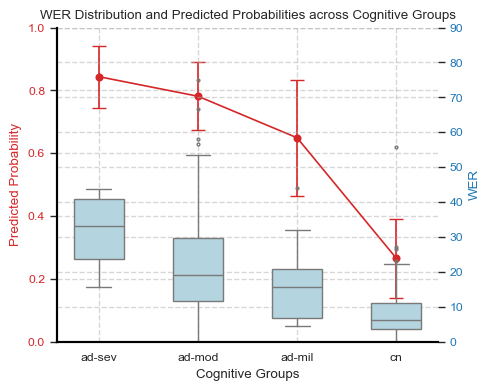

In [77]:
group_order = ['ad-sev', 'ad-mod', 'ad-mil', 'cn']
df_plot['mmse_split'] = df_plot['mmse_split'].astype(str).str.strip()

group_stats = df_plot.groupby('mmse_split').agg(
    mean_pred=('mean_pred', 'mean'),
    std_pred=('mean_pred', 'std')
).reindex(group_order)

groups = group_stats.index.tolist()
mean_preds = group_stats['mean_pred'].values
std_preds = group_stats['std_pred'].values

with plotting.paper_theme():
    plt.close()
    fig, ax1 = plt.subplots(figsize=(5, 4))

    # Right Y-axis: WER boxplot
    ax2 = ax1.twinx()
    sns.boxplot(data=df_plot, x='mmse_split', y='wer', order=group_order,
                ax=ax2, color='lightblue', width=0.5, fliersize=2)
    ax2.set_ylabel('WER', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim(0, df_plot['wer'].max() * 1.2)

    # Left Y-axis: Predicted probs with std error lines
    ax1.errorbar(groups, mean_preds, yerr=std_preds, fmt='o-', color='tab:red',
                ecolor='tab:red', capsize=5, label='Predicted Probabilities')
    ax1.set_ylabel('Predicted Probability', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_ylim(0, 1)

    # X-axis styling
    ax1.set_xlabel('Cognitive Groups')
    ax1.set_title('WER Distribution and Predicted Probabilities across Cognitive Groups')
    ax1.grid(True, axis='y')
    fig.tight_layout()

    plt.show()


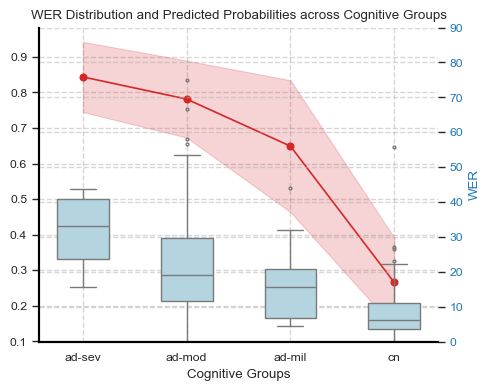

In [78]:
group_order = ['ad-sev', 'ad-mod', 'ad-mil', 'cn']
df_plot['mmse_split'] = df_plot['mmse_split'].astype(str).str.strip()

# Step 2: Grouped statistics for predicted probability
group_stats = df_plot.groupby('mmse_split').agg(
    mean_pred=('mean_pred', 'mean'),
    std_pred=('mean_pred', 'std')
).reindex(group_order)

groups = group_stats.index.tolist()
mean_preds = group_stats['mean_pred'].values
std_preds = group_stats['std_pred'].values

with plotting.paper_theme():
    plt.close()
    fig, ax1 = plt.subplots(figsize=(5, 4))

    ax2 = ax1.twinx()
    sns.boxplot(data=df_plot, x='mmse_split', y='wer', order=group_order,
                ax=ax2, color='lightblue', width=0.5, fliersize=2)
    ax2.set_ylabel('WER', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim(0, df_plot['wer'].max() * 1.2)

    # Numeric x positions for plotting
    x_pos = np.arange(len(groups))

    ax1.plot(x_pos, mean_preds, marker='o', color='tab:red', label='Mean Prediction')
    ax1.fill_between(x_pos, mean_preds - std_preds, mean_preds + std_preds, 
                    alpha=0.2, color='tab:red', label='±1 std')

    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(groups)

    ax1.set_xlabel('Cognitive Groups')
    ax1.set_title('WER Distribution and Predicted Probabilities across Cognitive Groups')
    ax1.grid(True, axis='y')
    fig.tight_layout()

    plt.show()
